<a href="https://colab.research.google.com/github/HungHoangDinh/GAN/blob/main/cGAN_using_pix2pix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pathlib
import datetime
from matplotlib import pyplot as plt
from IPython import display
import tensorflow as tf
tf.__version__

'2.19.0'

Downloading the datasets

In [2]:
dataset="maps"

In [3]:
dataset_file="{}.tar.gz".format(dataset)
dataset_url="http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/{}".format(dataset_file)
print(dataset_url)

http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/maps.tar.gz


In [4]:
download_zip=tf.keras.utils.get_file(fname=dataset_file,origin=dataset_url,extract=True)

250242400/250242400 ━━━━━━━━━━━━━━━━━━━━ 119s 0us/step


In [5]:
download_zip=pathlib.Path(download_zip)
path=download_zip.parent/dataset

In [6]:
path

PosixPath('/root/.keras/datasets/maps')

In [7]:
list(path.parent.iterdir())

[PosixPath('/root/.keras/datasets/maps.tar.gz'),
 PosixPath('/root/.keras/datasets/maps_extracted')]

In [8]:
sample = tf.io.read_file(str('/root/.keras/datasets/maps_extracted/maps/train/3.jpg'))
sample = tf.io.decode_jpeg(sample)

(600, 1200, 3)


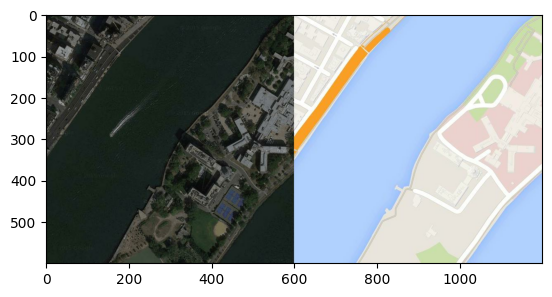

In [9]:
print(sample.shape)
plt.figure()
plt.imshow(sample)

In [10]:
def load_image(image_file):
  image=tf.io.read_file(image_file)
  image=tf.io.decode_jpeg(image)
  image=tf.image.resize(image, [256,512])
  width = tf.shape(image)[1]
  width=width//2
  input_image=image[:,:width,:]
  real_image=image[:,width:,:]
  input_image=tf.cast(input_image,tf.float32)
  real_image=tf.cast(real_image,tf.float32)
  return input_image,real_image

In [11]:
dataset_path="/root/.keras/datasets/maps_extracted/maps"

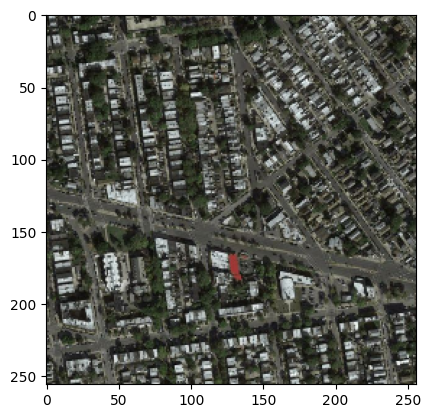

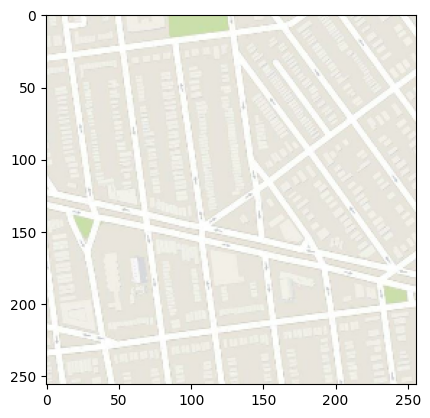

In [12]:
input_image,real_image=load_image(str(pathlib.Path(dataset_path)/'train/1.jpg'))
plt.figure()
plt.imshow(input_image/255.0)
plt.figure()
plt.imshow(real_image/255.0)

In [13]:
quantity_traning=tf.data.Dataset.list_files(dataset_path+'/train/*.jpg')


In [14]:
buffer_size=len(list(quantity_traning))

In [15]:
buffer_size
batch_size=1
img_wight=256
img_hight=256

In [16]:
def resize(original_image,transform_image, width, height):
  original_image=tf.image.resize(original_image, [width,height],method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  transform_image=tf.image.resize(transform_image, [width,height],method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  return original_image,transform_image

In [17]:
def normalize(original_image, trasform_image):
  original_image=(original_image/127.5)-1
  trasform_image=(trasform_image/127.5)-1
  return original_image,trasform_image

In [18]:
def random_crop(original_image, transform_image):
  stacked_image=tf.stack([original_image,transform_image],axis=0)
  cropped_image=tf.image.random_crop(stacked_image,size=[2,img_wight,img_hight,3])
  return cropped_image[0],cropped_image[1]

In [19]:
@tf.function()
def random_jitter(original_image,transform_image):
  original_image,transform_image=resize(original_image,transform_image,286,286)
  original_image,transform_image=random_crop(original_image,transform_image)
  if tf.random.uniform(())>0.5:
    original_image=tf.image.flip_left_right(original_image)
    transform_image=tf.image.flip_left_right(transform_image)
  return original_image,transform_image

Loading the dataset

In [20]:
def load_training_images(img_file):
  original_img, transformed_img=load_image(img_file)
  original_img,transformed_img=random_jitter(original_img,transformed_img)
  original_img,transformed_img=normalize(original_img,transformed_img)
  return original_img,transformed_img
#

In [21]:
def load_testing_images(img_file):
  original_img, transformed_img=load_image(img_file)
  original_img,transformed_img=resize(original_img,transformed_img,img_wight,img_hight)
  original_img,transformed_img=normalize(original_img,transformed_img)
  return original_img,transformed_img
#


In [22]:
training_dataset=tf.data.Dataset.list_files(dataset_path+'/train/*.jpg')
training_dataset=training_dataset.map(load_training_images,num_parallel_calls=tf.data.experimental.AUTOTUNE)
training_dataset=training_dataset.shuffle(buffer_size)
training_dataset=training_dataset.batch(batch_size)

In [23]:
training_dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None))>

In [24]:
try:
  testing_dataset=tf.data.Dataset.list_files(dataset_path+'/val/*.jpg')
  testing_dataset=testing_dataset.map(load_testing_images)
  testing_dataset=testing_dataset.batch(batch_size)
except:
  print("No testing dataset")
  pass

In [25]:
len(list(testing_dataset))

1098

In [26]:
import tensorflow as tf
from tensorflow.keras import layers
import time
from IPython.display import clear_output

In [27]:
def downsample(filters, apply_batchnorm=True):
  initializer=tf.random_normal_initializer(0.,0.02)
  block=tf.keras.Sequential()
  block.add(layers.Conv2D(filters,kernel_size=4,strides=2,padding='same',kernel_initializer=initializer,use_bias=False))
  if apply_batchnorm:
    block.add(layers.BatchNormalization())
  block.add(layers.LeakyReLU())
  return block

In [28]:
def upsample(filters,apply_dropout=False):
  initializer=tf.random_normal_initializer(0.,0.02)
  block=tf.keras.Sequential()
  block.add(layers.Conv2DTranspose(filters,kernel_size=4,strides=2,padding='same',kernel_initializer=initializer,use_bias=False))
  if apply_dropout:
    block.add(layers.Dropout(0.5))
  block.add(layers.BatchNormalization())
  block.add(layers.ReLU())
  return block

In [29]:
def Generator():
    inputs = layers.Input(shape=[256, 256, 3])

    # ------------------------
    #  Downsampling (Encoder)
    # ------------------------
    down1 = downsample(64, apply_batchnorm=False)(inputs)    # (128,128,64)
    down2 = downsample(128)(down1)                           # (64,64,128)
    down3 = downsample(256)(down2)                           # (32,32,256)
    down4 = downsample(512)(down3)                           # (16,16,512)
    down5 = downsample(512)(down4)                           # (8,8,512)
    down6 = downsample(512)(down5)                           # (4,4,512)
    down7 = downsample(512)(down6)                           # (2,2,512)
    down8 = downsample(512, apply_batchnorm=False)(down7)    # (1,1,512)

    # ------------------------
    #  Upsampling (Decoder)
    # ------------------------
    up1 = upsample(512, apply_dropout=True)(down8)
    up1 = layers.Concatenate()([up1, down7])

    up2 = upsample(512, apply_dropout=True)(up1)
    up2 = layers.Concatenate()([up2, down6])

    up3 = upsample(512, apply_dropout=True)(up2)
    up3 = layers.Concatenate()([up3, down5])

    up4 = upsample(512)(up3)
    up4 = layers.Concatenate()([up4, down4])

    up5 = upsample(256)(up4)
    up5 = layers.Concatenate()([up5, down3])

    up6 = upsample(128)(up5)
    up6 = layers.Concatenate()([up6, down2])

    up7 = upsample(64)(up6)
    up7 = layers.Concatenate()([up7, down1])

    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(
        3, 4, strides=2, padding='same',
        kernel_initializer=initializer, activation='tanh'
    )(up7)

    return tf.keras.Model(inputs=inputs, outputs=last)


In [30]:
generator=Generator()

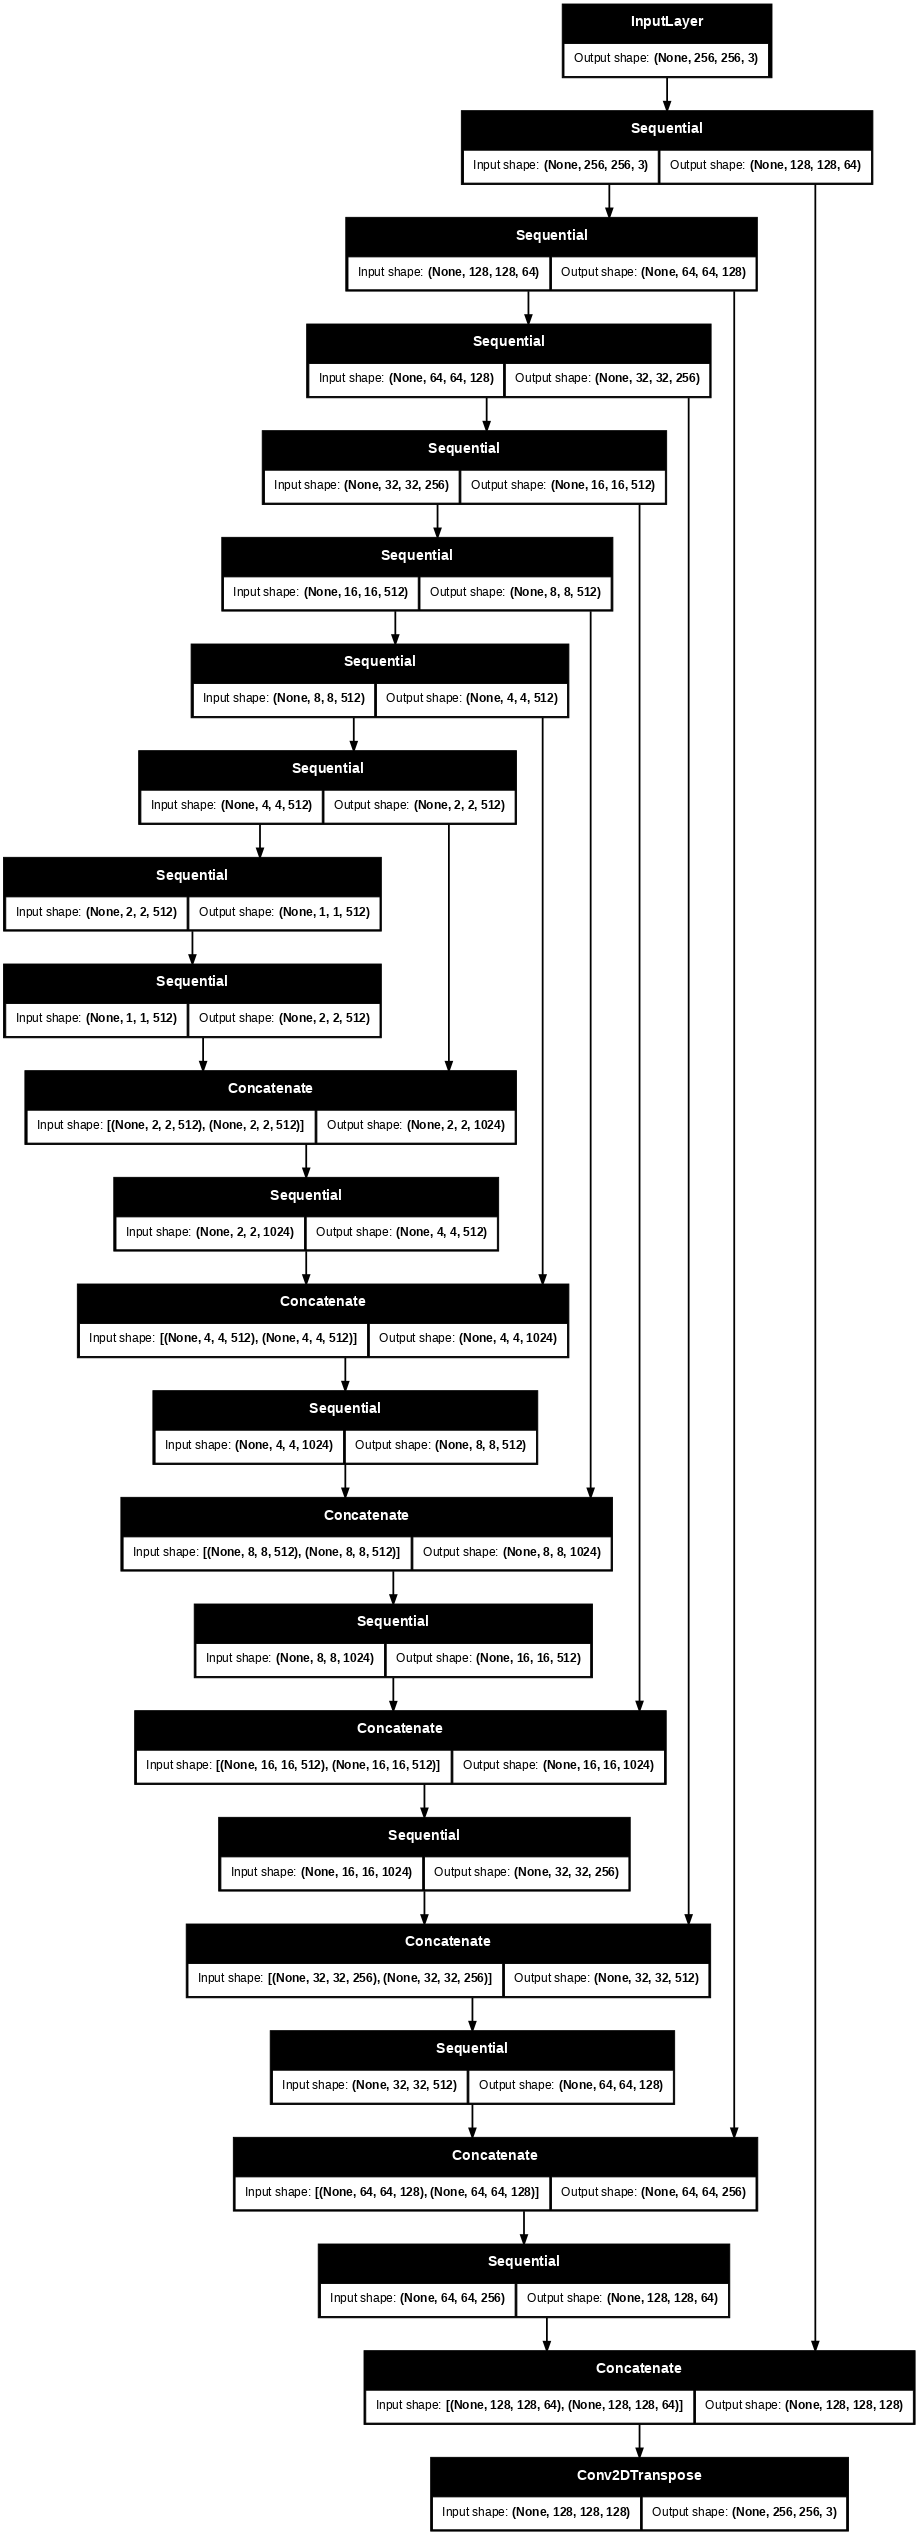

In [31]:
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

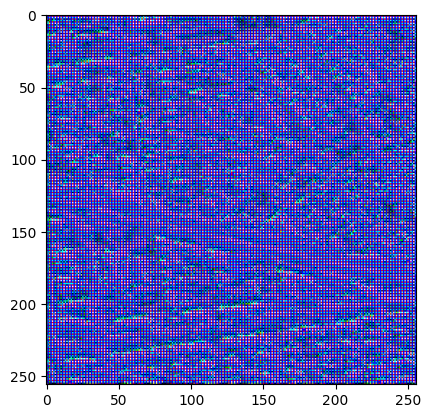

In [32]:
g_output=generator(input_image[tf.newaxis,...],training=False)
plt.imshow(g_output[0,...])

In [33]:
lr=0.02
beta1,beta2=0.5,0.999
lamda=100
loss=tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [54]:
@tf.function
def generator_loss(d_generated_output,g_output, target):
  gan_loss=loss(tf.ones_like(d_generated_output),d_generated_output)
  l1_loss=tf.reduce_mean(tf.abs(target-g_output))
  return gan_loss+lamda*l1_loss,gan_loss,l1_loss

In [36]:
def Discriminator():
  initializer=tf.random_normal_initializer(0.,0.02)
  inp=layers.Input(shape=[256,256,3],name='input_image')
  tar=layers.Input(shape=[256,256,3],name='target_image')
  x=layers.concatenate([inp,tar])
  down1=downsample(64,apply_batchnorm=False)(x)
  down2=downsample(128)(down1)
  down3=downsample(256)(down2)
  zero_pad1=layers.ZeroPadding2D()(down3)
  conv=layers.Conv2D(512,4,strides=1,kernel_initializer=initializer,use_bias=False)(zero_pad1)
  batchnorm1=layers.BatchNormalization()(conv)
  leaky_relu=layers.LeakyReLU()(batchnorm1)
  zero_pad2=layers.ZeroPadding2D()(leaky_relu)
  last=layers.Conv2D(1,4,strides=1,kernel_initializer=initializer)(zero_pad2)
  return tf.keras.Model(inputs=[inp,tar],outputs=last)

In [56]:
def discriminator_loss(real_output,generated_output):
  real_loss=loss(tf.ones_like(real_output),real_output)
  generated_loss=loss(tf.zeros_like(generated_output),generated_output)
  total_loss=real_loss+generated_loss
  return total_loss

In [37]:
generator_optimizer=tf.keras.optimizers.Adam(2*lr,beta_1=beta1,beta_2=beta2)
discriminator_optimizer=tf.keras.optimizers.Adam(lr,beta_1=beta1,beta_2=beta2)

In [40]:
discriminator=Discriminator()

In [41]:
checkpoint_dir='./training_checkpoints'
checkpoint_prefix=os.path.join(checkpoint_dir,'ckpt')
checkpoint=tf.train.Checkpoint(generator_optimizer=generator_optimizer,discriminator_optimizer=discriminator_optimizer,generator=generator,discriminator=discriminator)

In [42]:
def generate_images(model, test_input, real,step=None):
  generated_img=model(test_input,training=True)
  fig=plt.figure(figsize=(12,8))
  display_list=[test_input[0],real[0],generated_img[0]]
  title=['Input Image','Real Image','Generated Image']
  for i in range(3):
    plt.subplot(1,3,i+1)
    plt.title(title[i])
    plt.imshow(display_list[i]*0.5+0.5)
    plt.axis('off')
  if step is not None:
    plt.savefig("Result pix2pixx step_{}.png".format(step), bbox_inches="tight")
    plt.show()

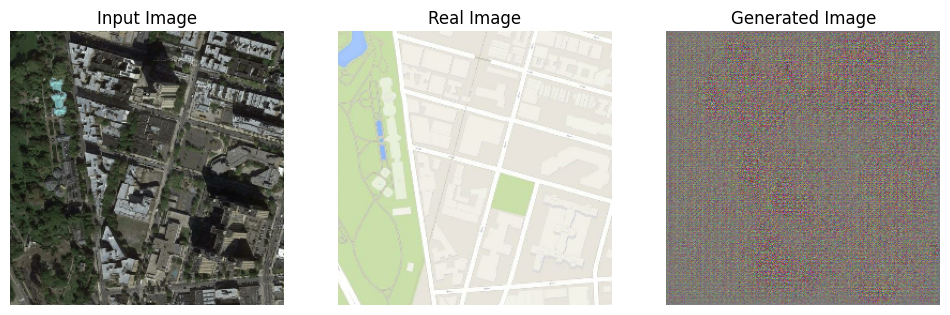

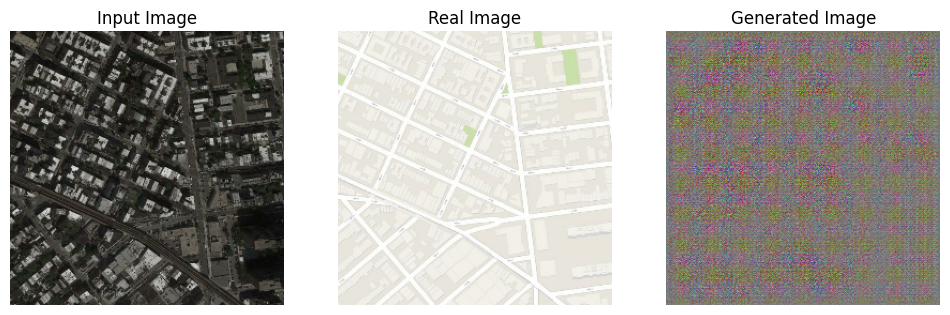

In [43]:
for input_example, real_example in testing_dataset.take(2):
  generate_images(generator,input_example,real_example)


In [44]:
path_log="logs/"
metrics=tf.summary.create_file_writer(path_log+ "fit/"+datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [58]:
@tf.function
def training_step(input_image,real_image,step):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    generated_image=generator(input_image,training=True)
    d_output_real=discriminator([input_image,real_image],training=True)
    d_output_generated=discriminator([input_image,generated_image],training=True)
    g_total_loss,gan_loss, l1_loss=generator_loss(d_output_generated,generated_image,real_image)
    d_total_loss=discriminator_loss(d_output_real,d_output_generated)
  generator_gradients=gen_tape.gradient(g_total_loss,generator.trainable_variables)
  discriminator_gradients=disc_tape.gradient(d_total_loss,discriminator.trainable_variables)
  with metrics.as_default():
    tf.summary.scalar('g_total_loss', g_total_loss, step=step//1000)
    tf.summary.scalar('gan_loss', gan_loss, step=step//1000)
    tf.summary.scalar('l1_loss', l1_loss, step=step//1000)
    tf.summary.scalar('d_loss', d_total_loss, step=step//1000)

In [60]:
def train(training_dataset,testing_dataset,steps):
  test_input,real_input=next(iter(testing_dataset.take(1)))
  start=time.time()
  for step,(input_image,real_image) in training_dataset.repeat().take(steps).enumerate():
    if step %1000==0:
      display.clear_output(wait=True)
      if step!=0:
        print("Time taken for 1000 steps: {} sec\n".format(time.time()-start))
      start=time.time()
      generate_images(generator,test_input,real_input,step)
      print("Step: {}".format(step//1000))
    training_step(input_image,real_image,step)
    if((step+1)%10)==0:
      checkpoint.save(file_prefix=checkpoint_prefix)
      generator.save_weights("model_pix2pix_generator.weights.h5")
      discriminator.save_weights("model_pix2pix_discriminator.weights.h5")



In [ ]:
%load_ext tensorboard
%tensorboard --logdir {path_log}


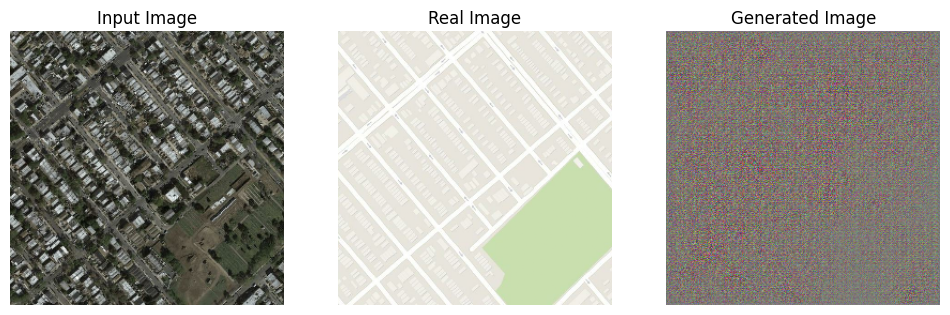

Step: 0


In [ ]:
train(training_dataset,testing_dataset,steps=20000)